Seasonal Agriculture Performance Analysis
Major Data Analytics Project
Domain: Agriculture **bold text**

Project Theme: Seasonal Agriculture Performance

Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

#2. Project Objectives

* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate and multivariate visualizations.
* Identify significant findings from the data.
* Develop evidence-based insights and recommendations.

# 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [4]:
file_path = "/content/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


4. Initial Data Understanding

In [5]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [6]:
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [7]:
df.tail (5)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [8]:
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [9]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [12]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


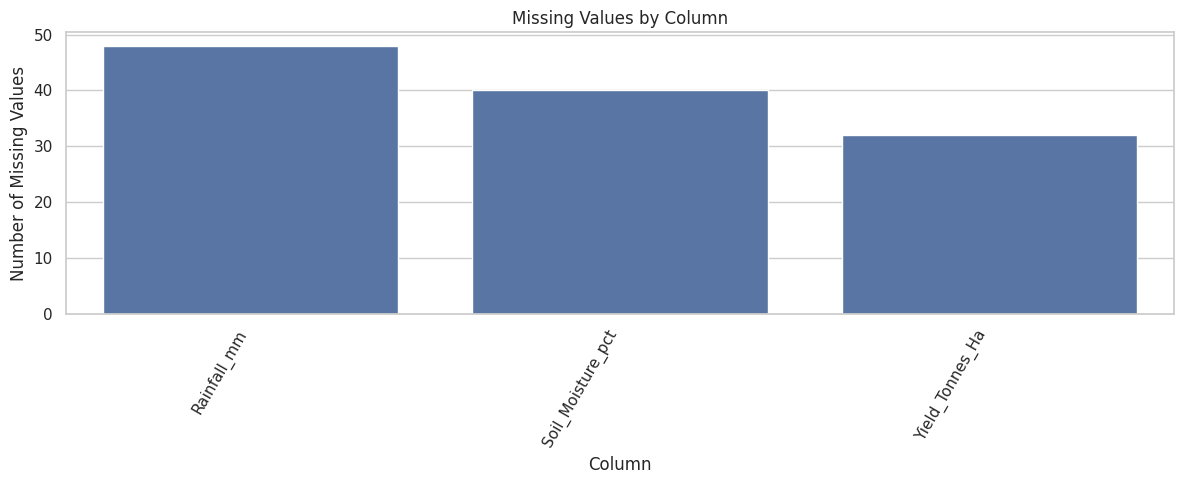

In [14]:
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [15]:
duplicate_count=df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [17]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [18]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [19]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


6. Feature / Variable Review

Review the available variables and classify them conceptually as:

* Identifier variables
* Categorical variables
* Numerical variables
* Environmental variables
* Operational variables
* Production/performance variables
* Economic variables

In [20]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


7. Statistical Analysis

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [21]:
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20,1315.20,464.75
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00,39.00,9.60
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [22]:
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,601.15,582.00,288.93,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.71,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [23]:
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      852.08 854.75 182.55   
Rabi                 7.75   7.68 4.18      436.00 430.30 175.66   
Zaid                 8.09   8.09 4.16      299.42 283.30 153.98   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.20   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.05   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.17   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.20 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.96         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.90         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.64   1.95 14.42             46.31  13.24 135.70   
Rabi              5.08   1.66 12.83             41.49  11.08 121.90   
Zaid              4.67   1.45 11.32             38.89   9.97 112.00   

       Market_Price_INR_Tonne                   Total_Cost_INR            \
                         mean   median      std           mean    median   
Season                                                                     
Kharif               44850.91 25793.00 30301.56      531804.41 524840.00   
Rabi                 44747.97 26041.00 30309.56      513836.58 506733.00   
Zaid                 44212.03 25749.50 30086.23      543976.73 534833.00   

                 Revenue_INR                     Profit_INR            \
             std        mean    median       std       mean    median   
Season                                                                  
Kharif 298487.69   710719.06 520196.00 708710.37  178914.65  38808.00   
Rabi   288386.89   601526.05 438156.00 584545.52   87689.47  -3187.00   
Zaid   297576.86   519171.90 373700.50 509524.55  -24804.82 -62144.00   

                 Water_Used_m3                 Water_Efficiency_t_per_1000m3  \
      

8. Univerate Analysis

Create and interpret suitable plots for:

* Important categorical variables
* Important numerical variables
* Seasonal distribution
* Production/performance distributions
* Economic distributions


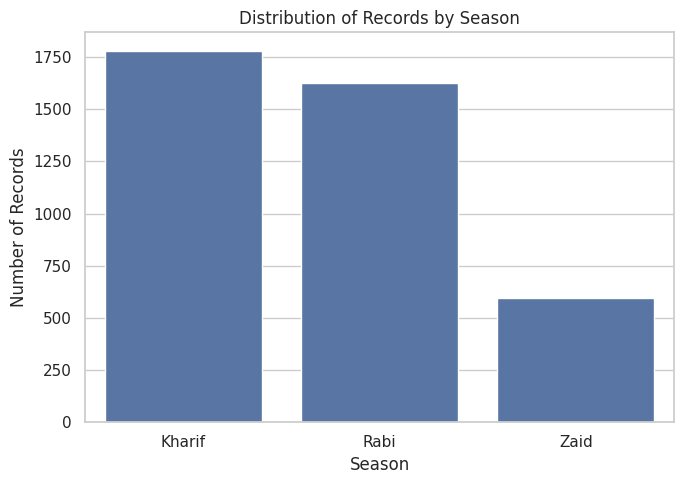

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

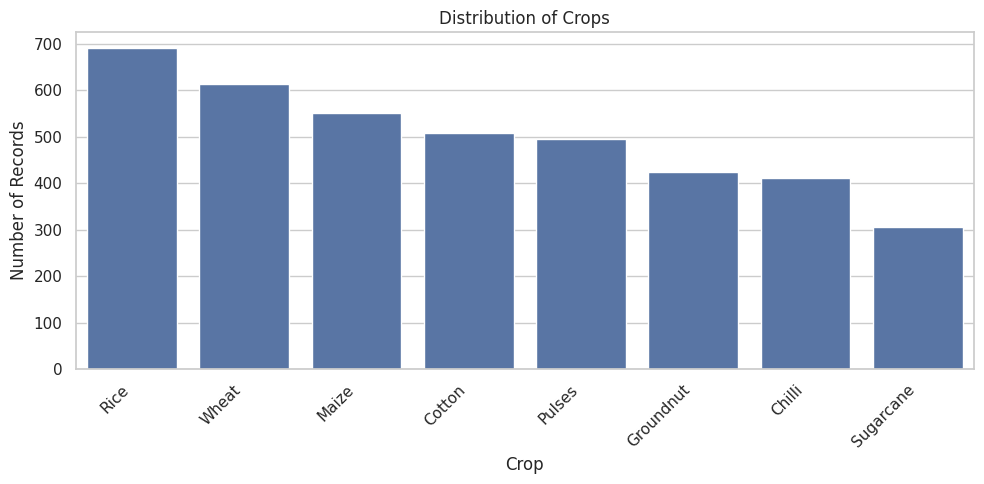

In [25]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

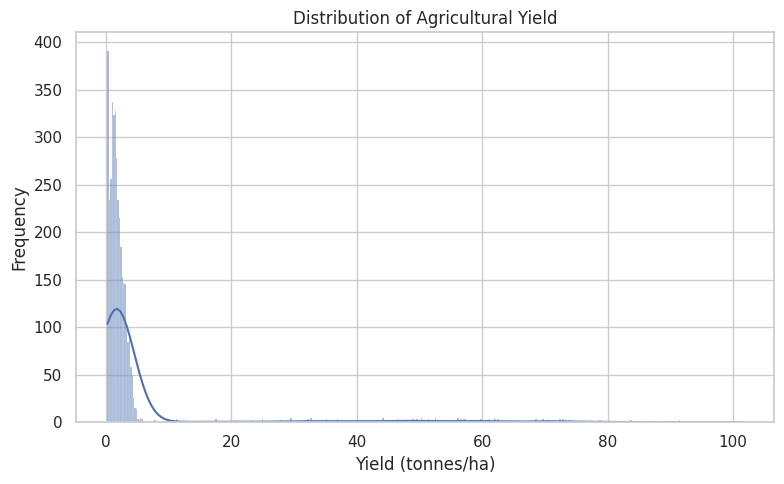

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

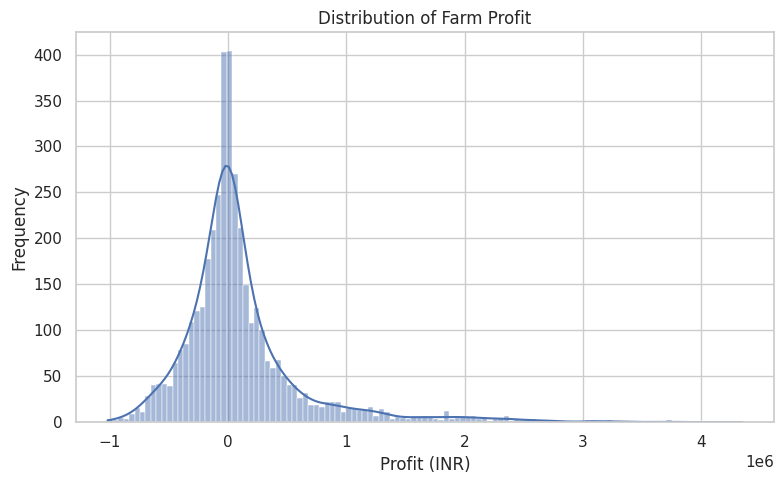

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

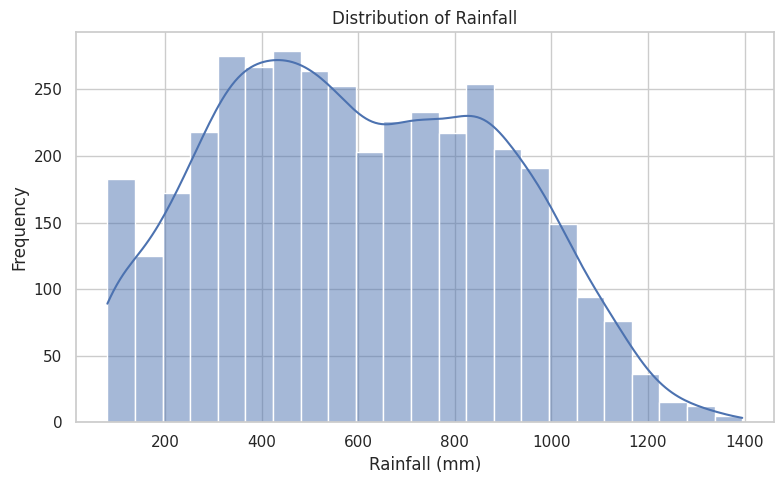

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

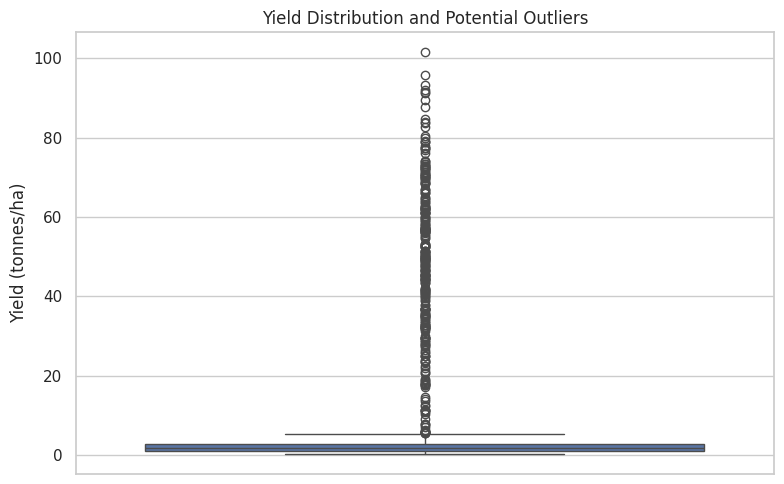

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

9. Outlier Analysis

Investigate potential outliers using statistical and visual methods.

Student task: Do not automatically delete outliers. Decide whether an extreme value is:

* A data-entry problem,
* A legitimate observation,
* Or something requiring further investigation.

Univariate: Season distribution (Pie Chart)

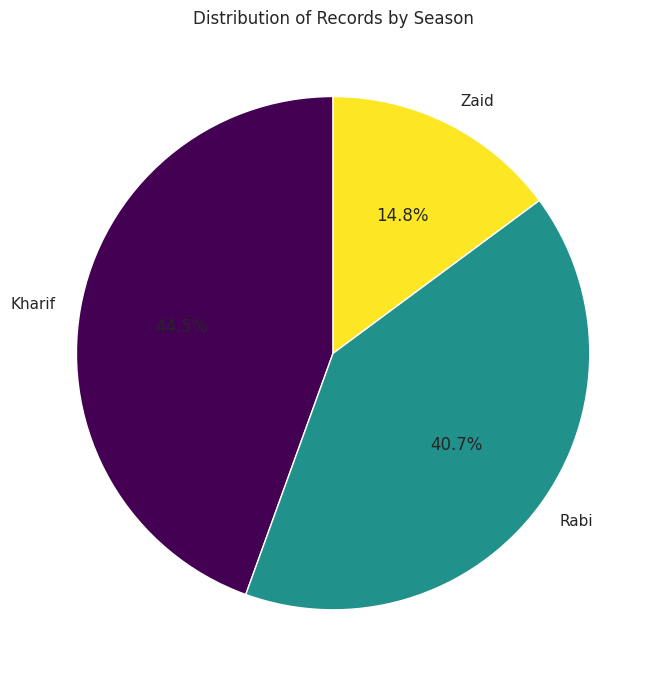

In [30]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [31]:
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.63,5.52,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


10. Bivariate Analysis

Bivariate analysis examines relationships or differences between two variables.

Students should investigate relationships that are relevant to the seasonal agriculture problem.



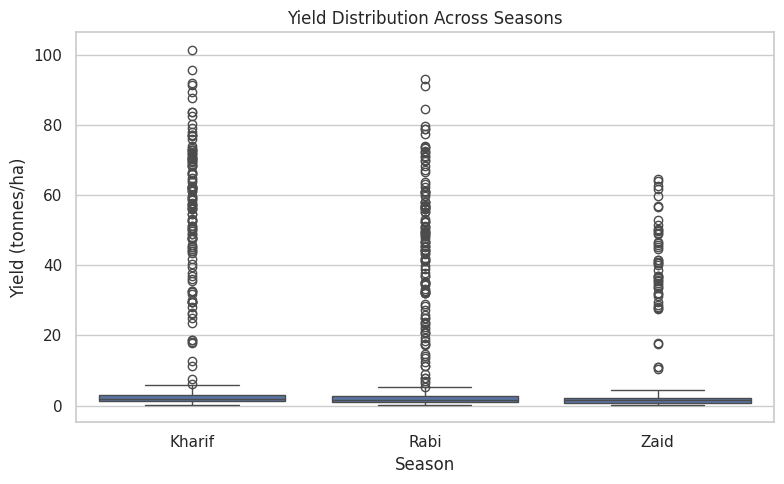

In [32]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

Bar plots for Bivariate Analysis

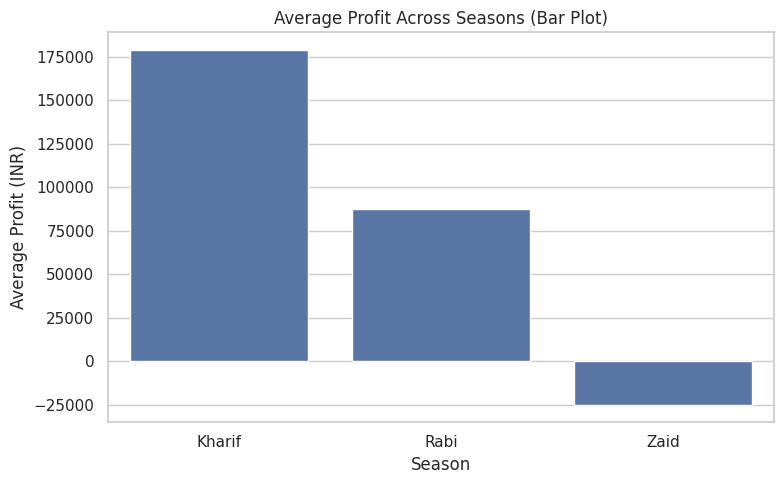

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

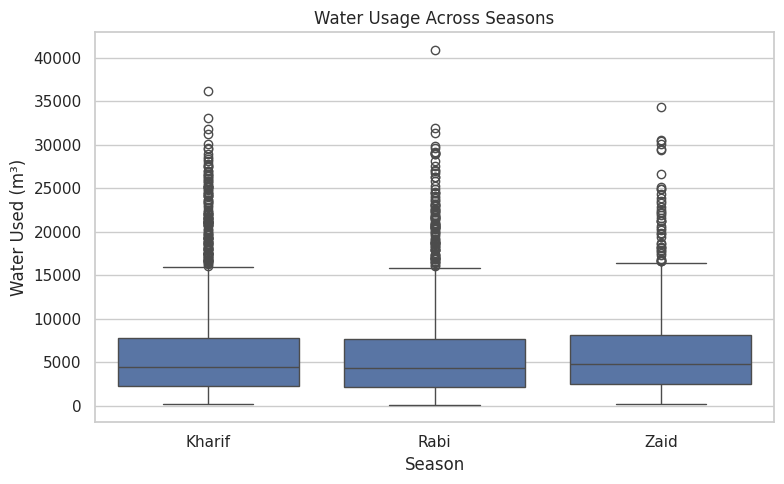

In [34]:
#Bivariate: Season vs Water Usage

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

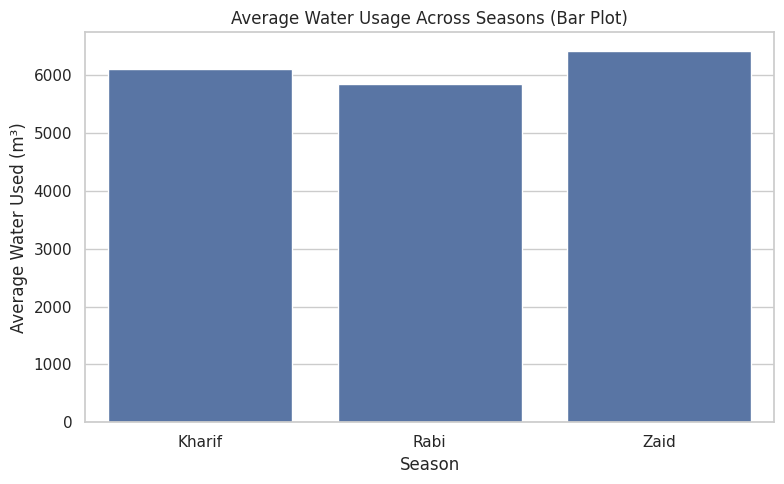

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

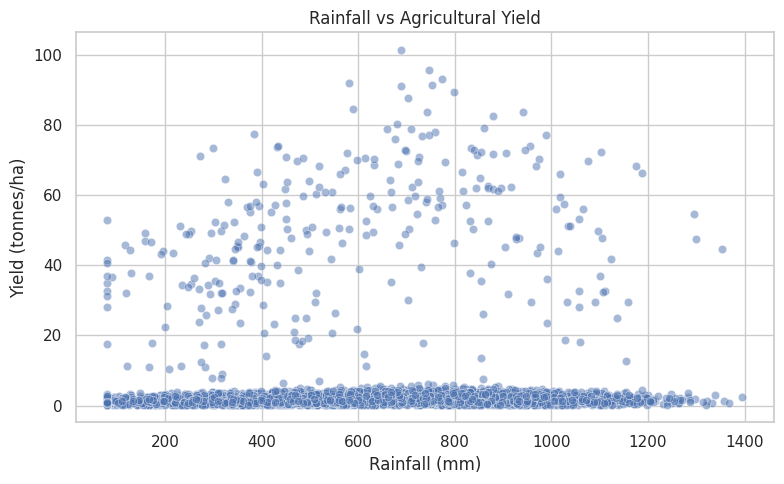

In [36]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

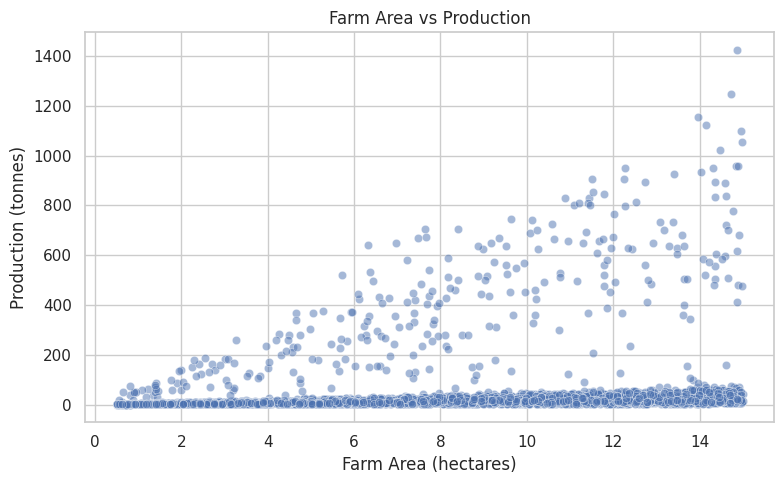

In [37]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

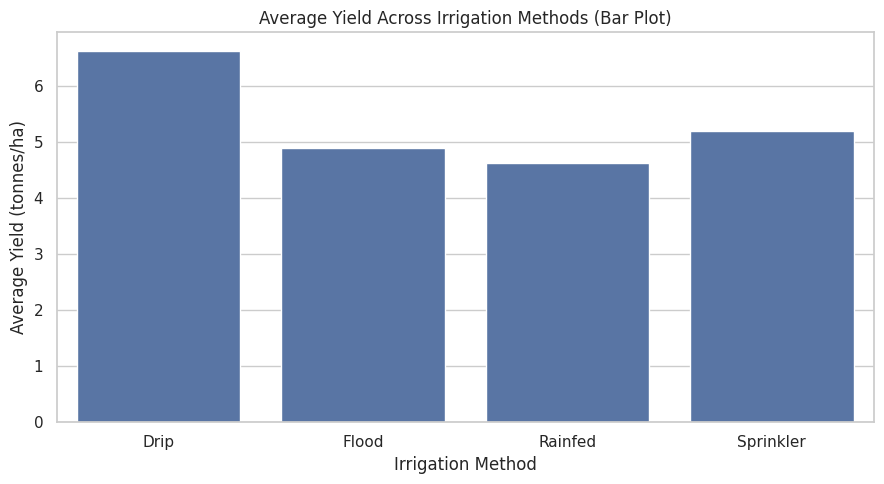

In [38]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

11. Multivariate Analysis

Multivariate analysis examines more than two variables together.

Use multivariate plots to investigate how season interacts with other dimensions such as crop type, resource usage or economic performance.



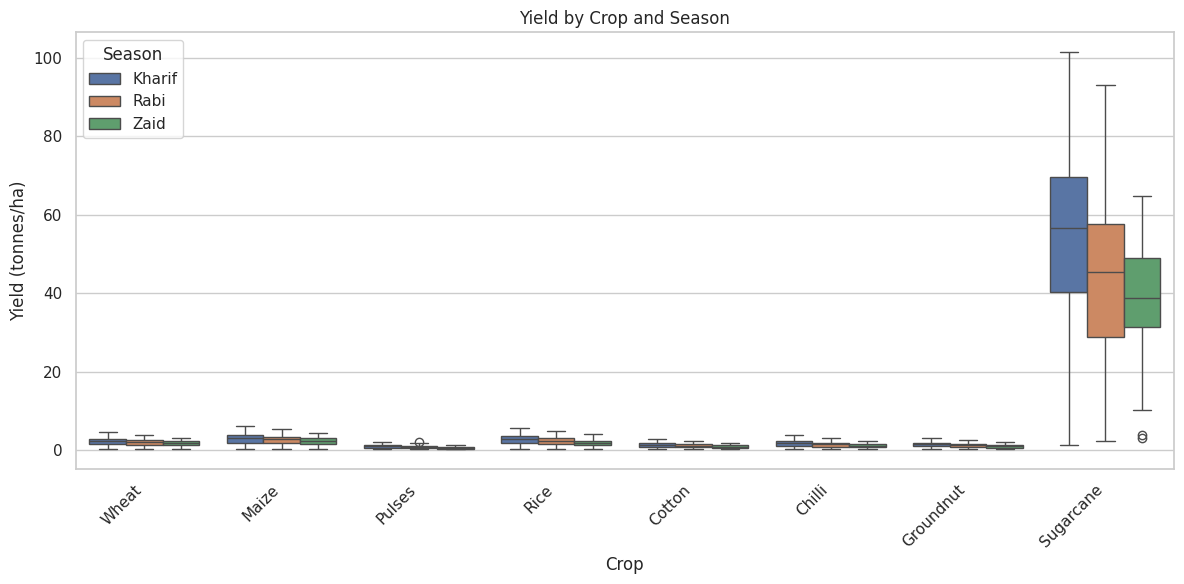

In [43]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

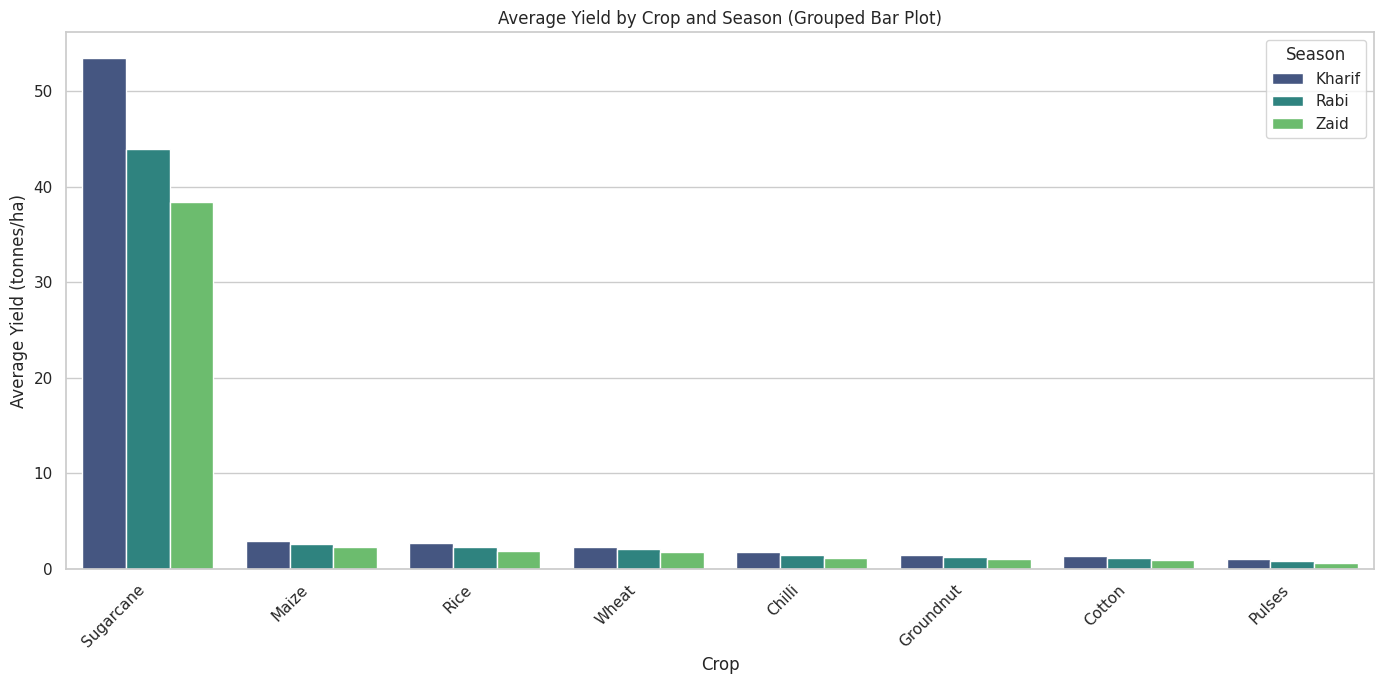

In [50]:
crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary.reset_index(), x='Crop', y='Average_Yield', hue='Season', palette='viridis')
plt.title('Average Yield by Crop and Season (Grouped Bar Plot)')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

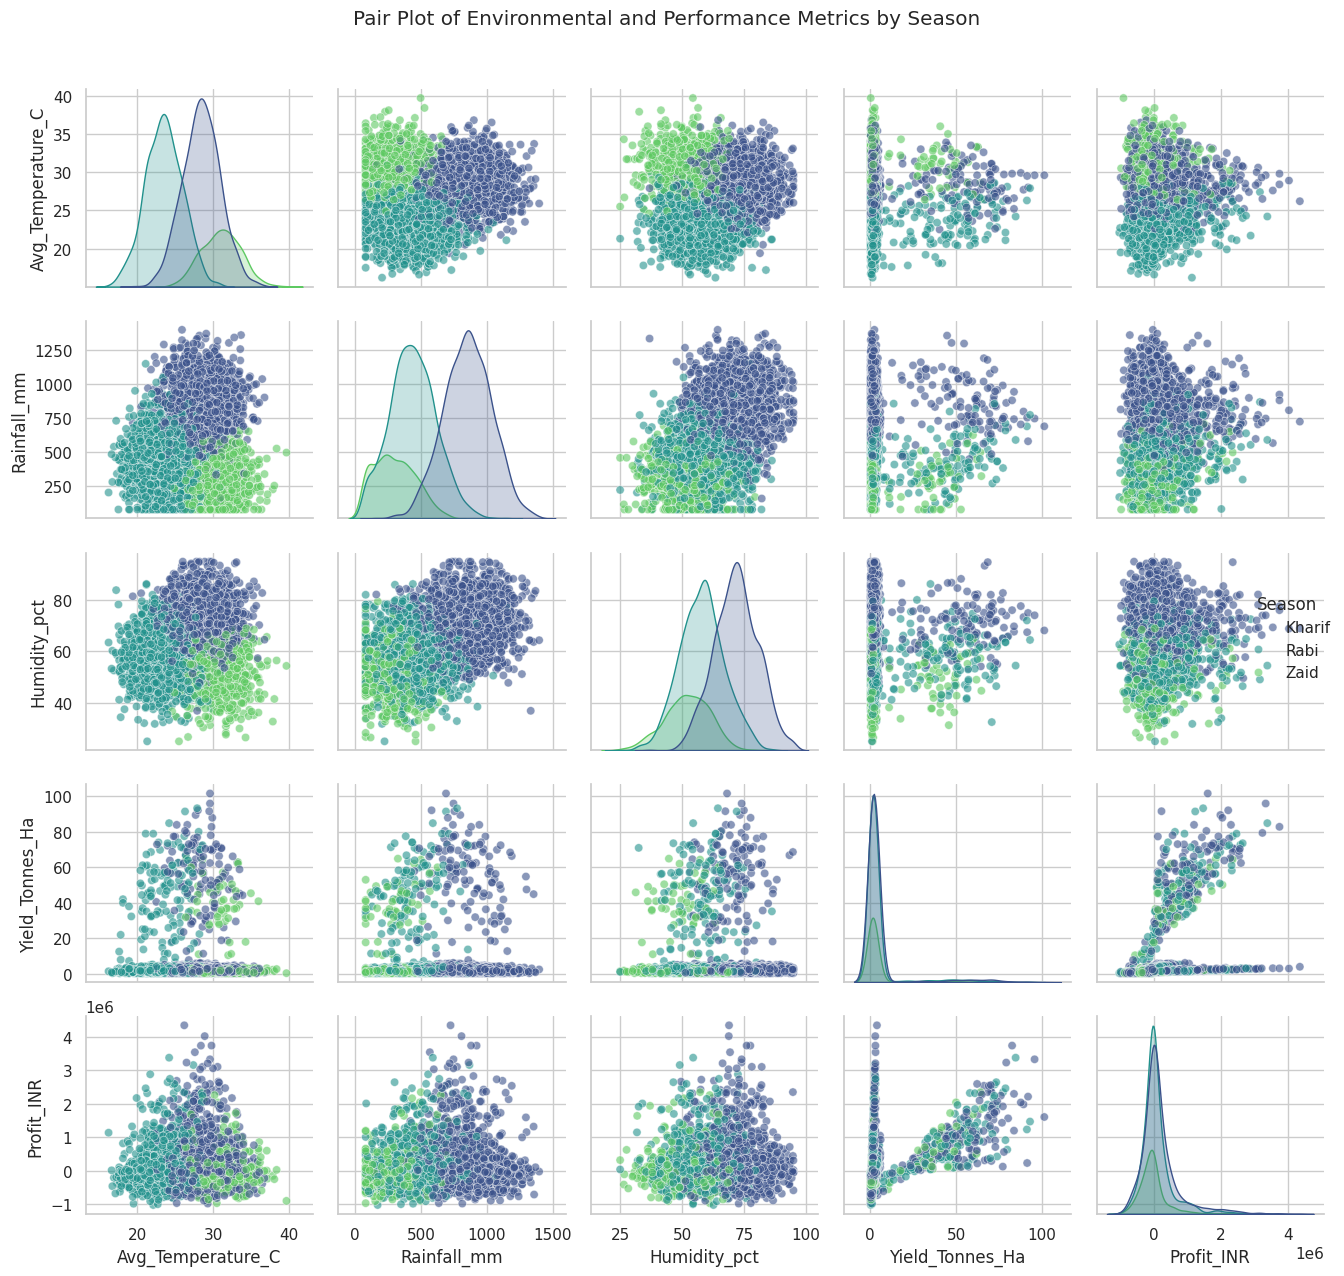

In [51]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust title position
plt.tight_layout()

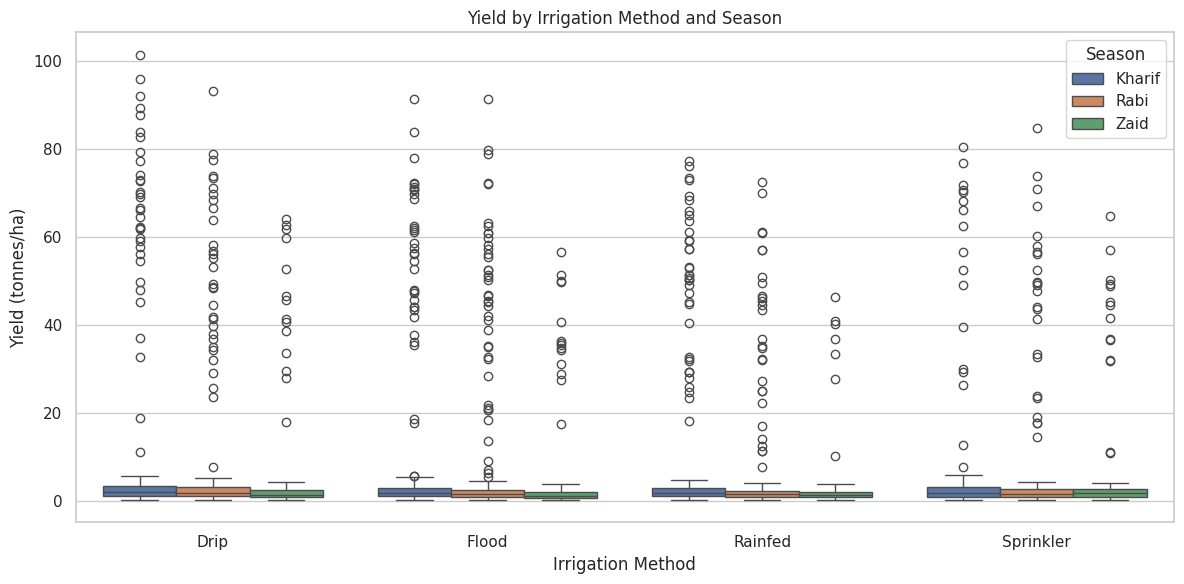

In [52]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

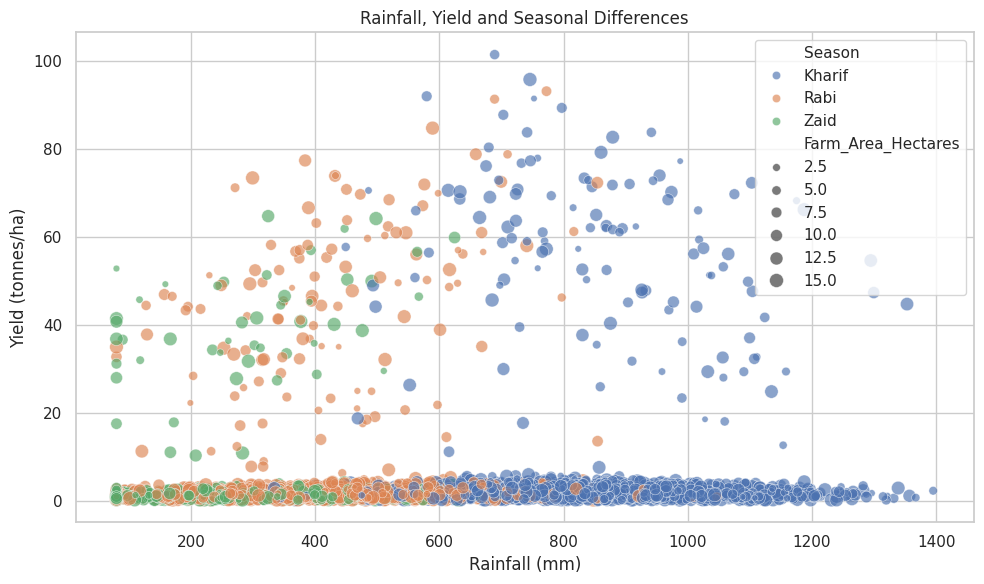

In [53]:
#Multivariate: Rainfall, yield and season


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 100),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

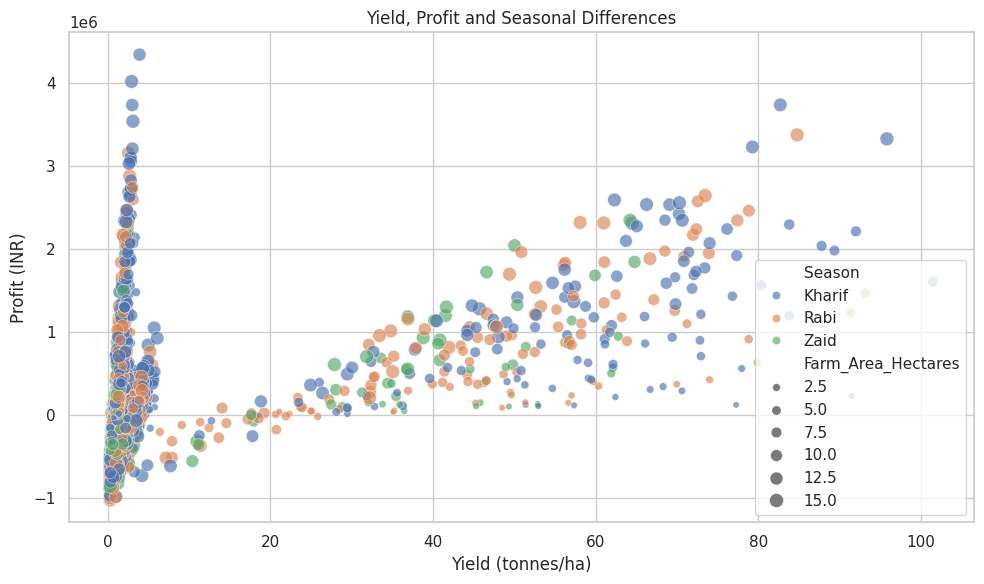

In [54]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 100),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

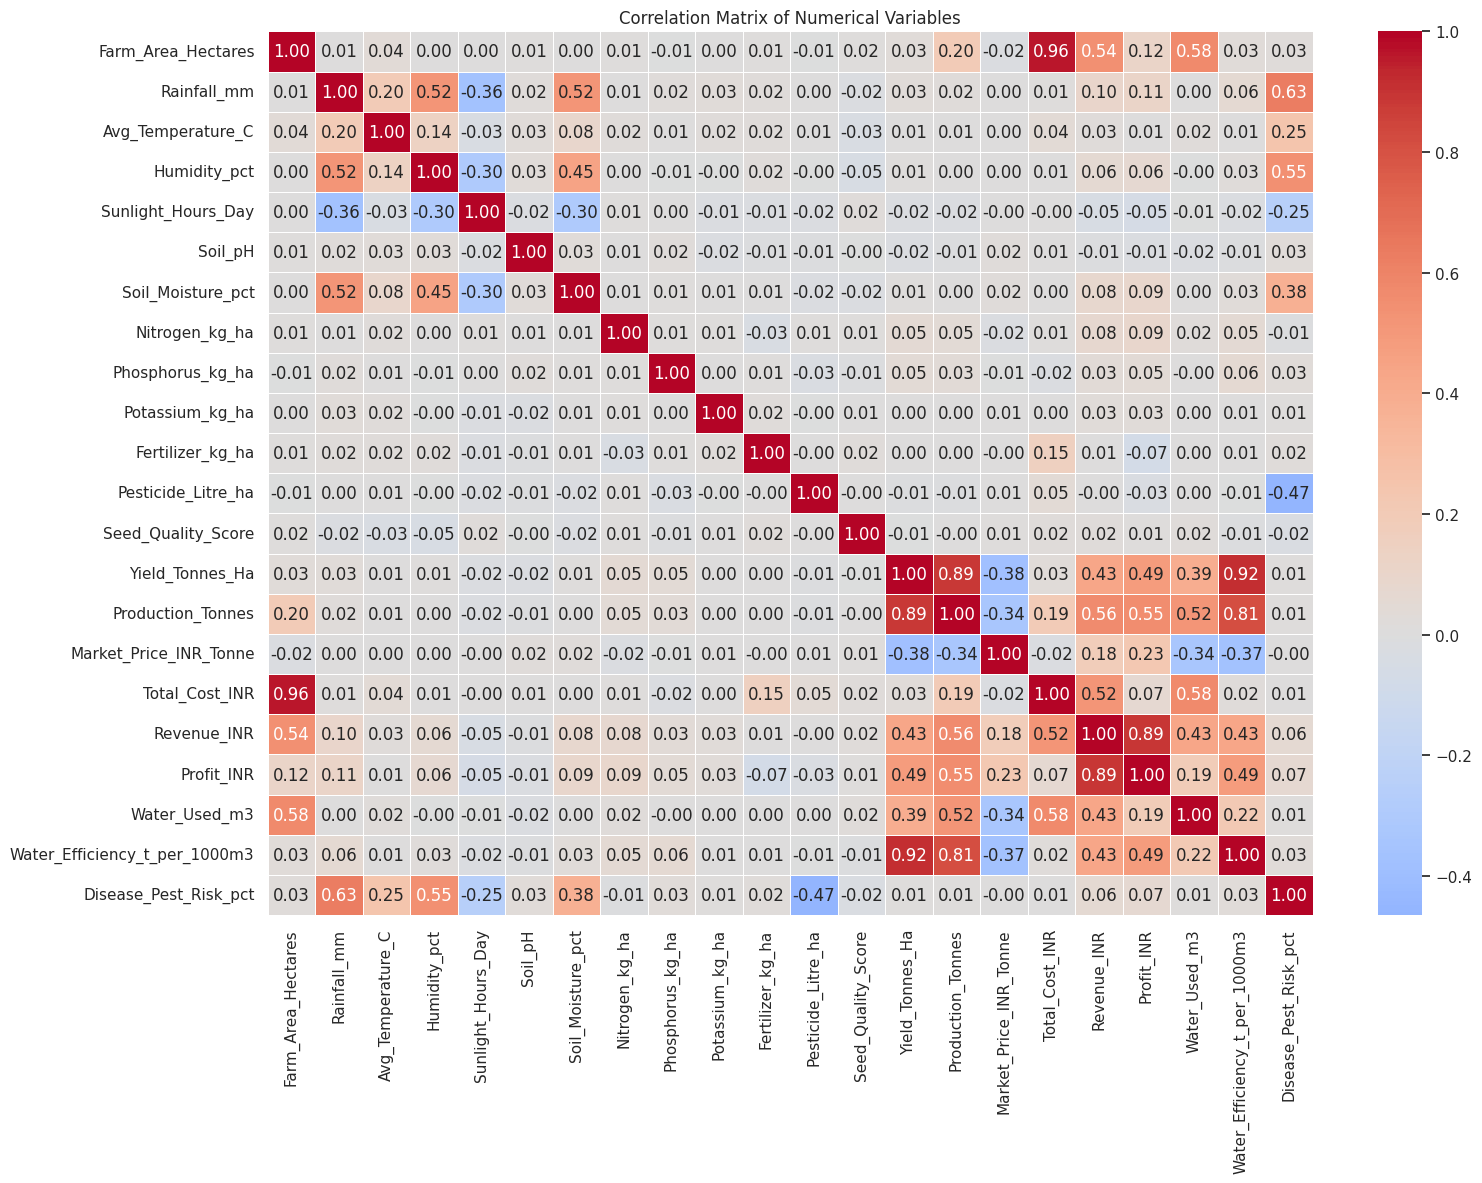

In [55]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

12. Seasonal Comparison

We should now move from individual plots to structured comparisons.

Task :

We create suitable summary tables and visualizations to compare seasons across meaningful measures.

We do not assume that every variable needs to be compared. Select variables that help answer the project problem.

In [56]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.64,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.08,67498.88,87689.47,142670768,5846.99
Zaid,594,4.67,23098.35,-24804.82,-14734066,6419.89


In [57]:
# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.71       -64903.40                      2.17
       Wheat               2.26      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.94       731612.86                     27.92
       Maize               2.61       -89133.40                      5.46
       Rice                2.33       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.46       638572.50                      2.89
       Groundnut           1.22        10416.54                      2.90
       Cotton              1.19       107343.59                      1.94
       Pulses              0.87       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.30      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.18       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.95       -53925.34                      1.49
       Pulses              0.65      -139227.81                      1.95

13. Additional Student-Driven Analysis

This section is intentionally open-ended.

Students should add at least 3 additional analyses that are not already provided above.

Possible directions include:

* Regional differences
* Crop-specific seasonal patterns
* Resource usage
* Economic performance
* Environmental conditions
* Risk patterns
* Relationships discovered during exploration

The student must explain why each additional analysis is relevant to the project problem.




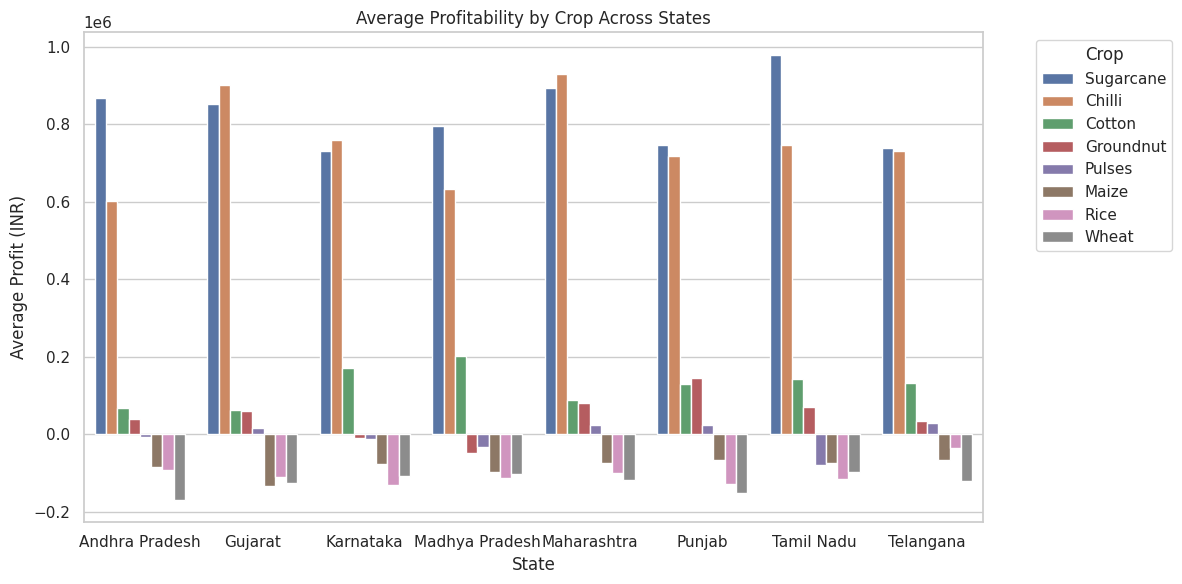

In [61]:
# Student Analysis 1

#Regional differences
# Question:
# How do crop yield and profitability vary across different states or regions, and which state-crop combinations generate the highest overall output?

# Analysis:
regional_summary = (
    df.groupby(["State", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Total_Production=("Yield_Tonnes_Ha", "sum")
    )
    .round(2)
    .sort_values(["State", "Average_Profit"], ascending=[True, False])
)
regional_summary

# Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=regional_summary.reset_index(),
    x="State",
    y="Average_Profit",
    hue="Crop"
)
plt.title("Average Profitability by Crop Across States")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.legend(title="Crop", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Interpretation:
# This analysis highlights spatial variations in crop yield and financial performance across states.
# Identifying regional disparities allows agricultural planners to reallocate farming infrastructure,
# target localized crop subsidies, and recommend optimal crop selections based on specific regional strengths.

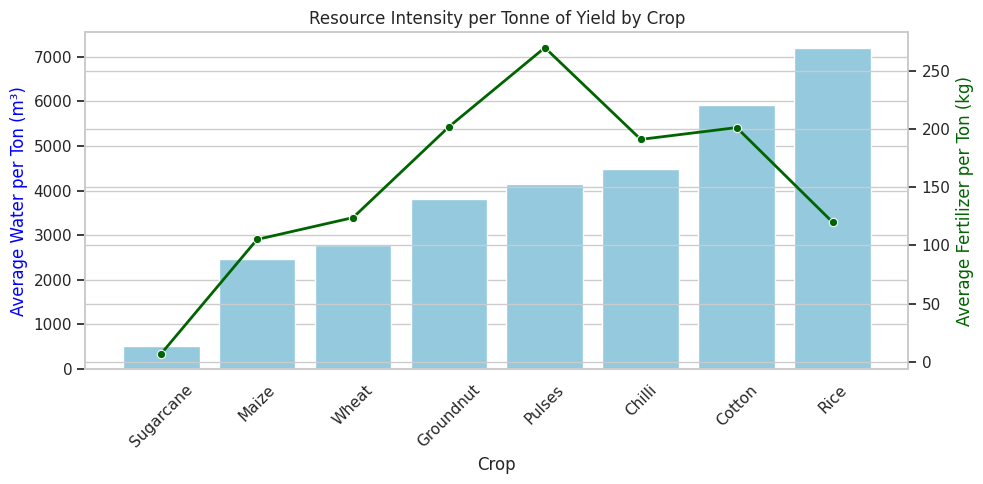

In [62]:
# Student Analysis 2

# Resource usage
# Question:
# How efficiently are resources (water and fertilizer) utilized per tonne of crop yield across different crops, and which crops require the most resource management optimization?

# Analysis:
df["Water_per_Ton"] = df["Water_Used_m3"] / df["Yield_Tonnes_Ha"]
df["Fertilizer_per_Ton"] = df["Fertilizer_kg_ha"] / df["Yield_Tonnes_Ha"]

resource_usage_summary = (
    df.groupby("Crop")
    .agg(
        Avg_Water_per_Ton=("Water_per_Ton", "mean"),
        Avg_Fertilizer_per_Ton=("Fertilizer_per_Ton", "mean"),
        Avg_Total_Water=("Water_Used_m3", "mean"),
        Avg_Total_Fertilizer=("Fertilizer_kg_ha", "mean")
    )
    .round(2)
    .sort_values("Avg_Water_per_Ton", ascending=True)
)
resource_usage_summary

# Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=resource_usage_summary.reset_index(),
    x="Crop",
    y="Avg_Water_per_Ton",
    color="skyblue",
    ax=ax1
)
ax1.set_ylabel("Average Water per Ton (m³)", color="blue")
ax1.set_title("Resource Intensity per Tonne of Yield by Crop")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(
    data=resource_usage_summary.reset_index(),
    x="Crop",
    y="Avg_Fertilizer_per_Ton",
    color="darkgreen",
    marker="o",
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel("Average Fertilizer per Ton (kg)", color="darkgreen")

plt.tight_layout()
plt.show()

# Interpretation:
# Lower values for resource consumption per tonne signify higher input efficiency. Measuring water
# and fertilizer intensity directly pinpoints wasteful agricultural practices, providing clear data
# to guide sustainable irrigation investments and precision fertilization programs.

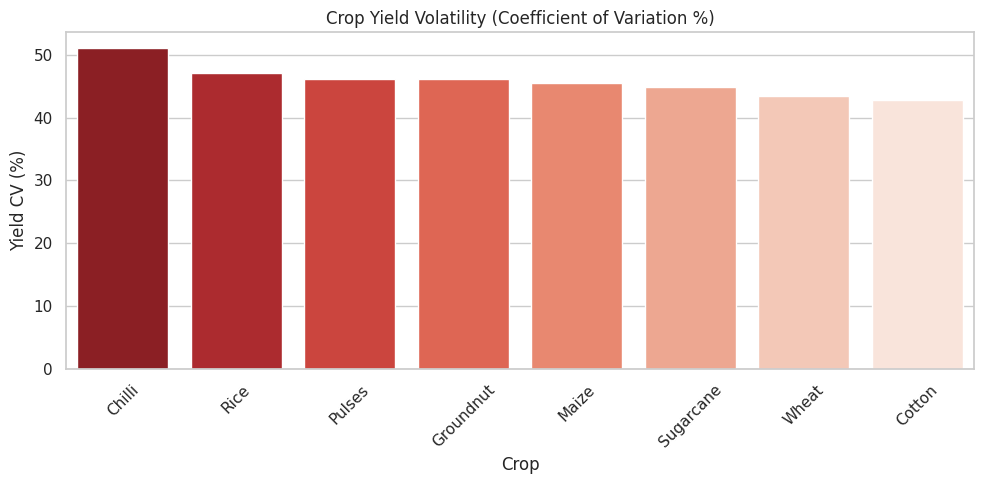

In [63]:
#Student Analysis 3: Risk Patterns


# Question:
# How do yield volatility and financial loss rates vary across different crops, and which crops carry the highest operational risk for farmers?
risk_patterns_summary = (
    df.groupby("Crop")
    .agg(
        Mean_Yield=pd.NamedAgg(column="Yield_Tonnes_Ha", aggfunc="mean"),
        Yield_Std_Dev=pd.NamedAgg(column="Yield_Tonnes_Ha", aggfunc="std"),
        Loss_Frequency_Count=pd.NamedAgg(column="Profit_INR", aggfunc=lambda x: (x < 0).sum()),
        Loss_Rate_Pct=pd.NamedAgg(column="Profit_INR", aggfunc=lambda x: (x < 0).mean() * 100)
    )
)

# Coefficient of Variation (CV) measures relative risk/volatility
risk_patterns_summary["Yield_CV_%"] = (
    risk_patterns_summary["Yield_Std_Dev"] / risk_patterns_summary["Mean_Yield"]
) * 100

risk_patterns_summary = (
    risk_patterns_summary.drop(columns=["Yield_Std_Dev"])
    .round(2)
    .sort_values("Yield_CV_%", ascending=False)
)
risk_patterns_summary

# Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=risk_patterns_summary.reset_index(),
    x="Crop",
    y="Yield_CV_%",
    hue="Crop", # Assign x variable to hue
    palette="Reds_r",
    legend=False # Set legend to False to avoid redundant legend
)
plt.title("Crop Yield Volatility (Coefficient of Variation %)")
plt.xlabel("Crop")
plt.ylabel("Yield CV (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interpretation:
# High Coefficient of Variation (Yield_CV_Pct) highlights crops with unpredictable production yields,
# while Loss_Rate_Pct pinpoints crops that frequently fail to turn a profit. Identifying these high-risk
# crops helps financial institutions, insurers, and agricultural planners set appropriate risk premiums
# and advise farmers on safer crop diversification strategies.

Insight 1 : How do crop yield and profitability vary across different states or regions, and which state-crop combinations generate the highest overall output?

1. Observation: Commercial cash crops (Sugarcane and Chilli) consistently generate vastly higher average profits (~₹600,000 to ₹1,000,000) across all states, whereas staple food grains (Maize, Rice, and Wheat) frequently record negative average profit margins.
2. Evidence: Grouped bar chart visualization for Regional Differences Analysis (`regional_summary`), showing tall positive bars for Sugarcane and Chilli alongside negative bars dipping below zero for Maize, Rice, and Wheat across Andhra Pradesh, Gujarat, Punjab, and other states.
3. Interpretation: Spatial market dynamics and high commercial valuation strongly favor cash crop cultivation, while staple food crops suffer from high production costs or low wholesale market prices that frequently exceed realized revenues.
4. Limitation: This finding does not prove that food grains are inherently unprofitable for every individual farmer, as government minimum support prices (MSP), local storage facilities, and post-harvest transport costs vary within state sub-regions.

Insight 2: How efficiently are resources (water and fertilizer) utilized per tonne of crop yield across different crops, and which crops require the most resource management optimization?

1. Observation: Sugarcane demonstrates the highest resource conversion efficiency (consuming under 1,000 m³ of water and ~10 kg of fertilizer per tonne), while Rice demands the highest water intensity (>7,000 m³/tonne) and Pulses require the peak fertilizer intensity (>250 kg/tonne).
2. Evidence: Dual-axis chart visualization for Resource Usage Efficiency (`resource_usage_summary`), showing the lowest sky-blue bar and dark-green line point for Sugarcane, the tallest blue bar for Rice, and the highest green peak for Pulses.
3. Interpretation : High biomass yields per hectare dilute Sugarcane's unit input intensity, whereas lower tonnage yields in crops like Pulses and Rice inflate their calculated resource consumption per output unit, requiring targeted precision input management.
4. Limitation: Measuring resource efficiency solely on a per-tonne basis does not account for absolute seasonal crop duration or natural environmental absorption (e.g., rainwater reliance vs. energy-intensive artificial irrigation).

 Insight 3 : How do yield volatility and financial loss rates vary across different crops, and which crops carry the highest operational risk for farmers?

1. Observation: Yield volatility (`Yield_CV_%`) spans from a peak of over 50% for Chilli down to roughly 42% for Cotton, with crops like Rice, Pulses, and Groundnut clustering around 46%.
2. Evidence: Bar chart visualization for Risk Patterns (`risk_patterns_summary`), showing the tallest dark red bar for Chilli, a middle cluster of bars near 45–47%, and the lowest light bar for Cotton.
3. Interpretation: High-volatility crops like Chilli carry substantial production risk due to yield unpredictability, whereas lower-CV crops like Cotton offer relatively greater output stability across farming cycles.
4. Limitation: High yield volatility does not automatically mean higher financial loss rates (`Loss_Rate_Pct`), as high-volatility cash crops can command premium market prices that mitigate volume drops.

**15. Recommendations**

Based only on the evidence found in the dataset, provide practical and data-driven recommendations.

Recommendations should:

* Clearly connect to an observed finding.
* Avoid unsupported assumptions.
* Acknowledge important limitations.
* Focus on what the data can reasonably support.

 Recommendation 1: Regional Crop Allocation & Subsidy Restructuring

Action: Reallocate regional agricultural subsidies and encourage farmers in low-performing states to transition land allocation toward high-value cash crops (Sugarcane and Chilli) while modernizing input supply chains for staple grains (Maize, Rice, and Wheat).
* Connection to Finding: Addresses Insight 1, which revealed that Sugarcane and Chilli yield substantial profits (~₹600,000 to ₹1,000,000) across all states, whereas staple food grains consistently produce negative average profit margins.
* Supported Data Boundary: Relies directly on state-level profitability aggregates (`regional_summary`) and avoids making speculative assumptions about individual farm-level overhead or unmeasured logistics costs.
* Limitation Acknowledgment: While high-value cash crops offer higher profit margins, recommendations must acknowledge that food security requirements and local Minimum Support Price (MSP) guarantees mean staple grain production cannot be entirely phased out.

 Recommendation 2: Target Precision Resource Interventions by Input Intensity

Action: Deploy precision drip irrigation systems specifically for high-water-intensity crops like Rice and optimize chemical application protocols for high-fertilizer-intensity crops like Pulses to reduce per-tonne resource consumption.

* Connection to Finding: Directly addresses Insight 2, which demonstrated that Rice consumes over 7,000 m³ of water per tonne while Pulses demand over 250kg of fertilizer per tonne, compared to Sugarcane's low unit consumption.
* Supported Data Boundary: Grounded strictly in the calculated resource usage metrics (`Avg_Water_per_Ton` and `Avg_Fertilizer_per_Ton`) within `resource_usage_summary`.
* Limitation Acknowledgment: Recommendations focus on output efficiency and do not assume uniform adoption rates, as hardware capital costs, total growing season durations, and reliance on natural rainfall versus pumped groundwater vary across farming regions.

 Recommendation 3: Tailored Agricultural Risk Mitigation & Insurance Indexing
* Action: Establish targeted crop insurance schemes and yield-stabilization support primarily for high-volatility crops like Chilli, while promoting mixed-cropping strategies alongside lower-volatility alternatives like Cotton to buffer operational risk.
* Connection to Finding: Directly aligns with Insight 3, which established that Chilli exhibits the highest yield volatility (CV > 50%), while Cotton provides the lowest production variation (~42%).
* Supported Data Boundary: Based strictly on the statistical Coefficient of Variation (`Yield_CV_%`) and profit loss metrics computed in `risk_patterns_summary`.
* Limitation Acknowledgment: While insurance and diversification mitigate production fluctuations, risk management frameworks must account for the fact that high-volatility cash crops can still achieve overall profitability through premium market prices during low-supply seasons.

**16. Conclusion**

This project analyzed the `seasonal_agriculture_performance_dataset` to understand how agricultural performance varies across seasons and to identify meaningful patterns, trends, and relationships. The dataset provided a rich source of farm-level records encompassing environmental conditions, farming practices, production, costs, revenue, and profit.

### Key Revelations and Patterns:

1.  Seasonal Impact on Profitability: The analysis clearly showed significant seasonal variations in agricultural performance, particularly in terms of profitability. The Kharif season consistently demonstrated the highest average profits, followed by Rabi, while the Zaid season often resulted in negative average profits. This highlights the critical role of seasonal conditions in determining economic outcomes for farmers.

2.  Crop-Specific Seasonal Performance: Certain crops perform better in specific seasons. Sugarcane, for instance, showed exceptionally high yields and profits across all seasons, but its average yield was highest in Kharif. Conversely, staple crops like Maize, Rice, and Wheat frequently experienced negative profit margins, suggesting they are less profitable under current conditions.

3.  Environmental Factors and Yield: Environmental variables like rainfall and temperature are crucial determinants of yield. While there is a positive correlation between rainfall and yield, other factors also play a significant role, as indicated by the scatter plots. Different irrigation methods also showed varying average yields.

4.  Resource Utilization Efficiency: There are considerable differences in resource efficiency across crops. Sugarcane demonstrated high water and fertilizer efficiency per tonne of yield due to its high biomass production, whereas crops like Rice and Pulses exhibited lower efficiencies, consuming more resources per unit of output.

5.  Regional Disparities: Crop profitability and yield vary significantly across different states. Cash crops like Sugarcane and Chilli often yield higher profits across various regions, while staple grains struggle to be profitable, reinforcing the need for region-specific agricultural strategies.

6.  Yield Volatility and Risk: Crops exhibit different levels of yield volatility. Chilli was identified as a high-volatility crop, indicating unpredictable production, while cotton showed greater stability. This insight is crucial for risk management and crop insurance strategies.

### Useful Analytical Findings:

*   Identification of High-Value Crops: Sugarcane and Chilli stand out as high-profit crops, suggesting potential for increased focus in suitable regions.
*   Resource Management Hotspots : Rice (high water usage) and Pulses (high fertilizer usage) were identified as areas requiring optimized resource management interventions to improve efficiency.
*   Risk Assessment for Farmers: The quantification of yield volatility provides a basis for farmers, insurers, and policymakers to assess and mitigate agricultural risks more effectively.
*   Season-Specific Strategies: The data supports tailoring crop selection, resource allocation, and support programs based on seasonal characteristics to maximize profitability and minimize losses.

### Important Limitations of the Analysis:

*   Missing Data Imputation: Missing values in Rainfall, Soil Moisture, and Yield were not explicitly addressed with advanced imputation techniques, which could slightly impact the accuracy of analyses involving these variables.
*   Outlier Handling: While outliers were identified, no specific treatment (e.g., capping, transformation) was applied, assuming they are legitimate extreme observations. This might skew some statistical measures and visual representations.
*   Causation vs. Correlation: The analysis primarily focused on identifying correlations and patterns. Establishing definitive causal relationships would require more controlled experiments or advanced statistical modeling.
*   Lack of Time-Series Data: Without specific time-series data (e.g., year-over-year performance), it's challenging to assess long-term trends or the impact of climate change over time.
*   Generalization:** Findings are based on the provided dataset and may not be universally generalizable to all agricultural contexts within India or globally without further validation.

### Support for Future Investigation or Decision-Making:

This analysis lays a strong foundation for data-driven decision-making in the agricultural sector. Future investigations could involve:

*   Predictive Modeling: Developing models to predict optimal crop choices, yields, and profits based on seasonal forecasts and resource availability.
*   **Economic Impact Assessment: Deeper dives into the economic factors driving profitability differences, including market demand, government policies, and supply chain efficiencies.
*   Environmental Optimization: Research into sustainable farming practices, precise irrigation techniques, and organic fertilization methods to improve resource efficiency further.
*   Risk Management Tools: Creating more sophisticated risk assessment tools and insurance products tailored to specific crops, regions, and seasonal volatilities.
*   Policy Recommendations: Informing agricultural policy decisions regarding subsidies, crop diversification, and environmental protection based on empirical evidence from data.

By understanding these patterns and relationships, stakeholders can make more informed decisions to enhance agricultural sustainability, profitability, and food security.

17. Project Checklist

Before submission, confirm that your notebook includes:

- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] At least 3 student-designed analyses completed
- [x] At least 8 meaningful insights documented
- [x] Evidence-based recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided